<a href="https://colab.research.google.com/github/jsanothernpc/Ayushman_4NI23CI021-ML2/blob/main/ML2SecondLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Pipeline
This notebook demonstrates a standard classification pipeline using `scikit-learn`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv('student_dataset.csv')

In [ ]:
print(df)

   Student_ID   Age  Gender  StudyHours  Attendance  Marks Result
0           1  18.0    Male         3.0        85.0   72.0   Pass
1           2  19.0  Female         5.0        92.0   88.0   Pass
2           3  18.0    Male         2.0        70.0   55.0   Pass
3           4  20.0  Female         6.0        95.0   91.0   Pass
4           5  19.0    Male         1.0        60.0   42.0   Fail
5           6  18.0  Female         NaN        88.0   76.0   Pass
6           7   NaN    Male         4.0         NaN   68.0   Pass
7           8  21.0  Female         2.0        65.0    NaN   Fail
8           9  19.0    Male         1.0        60.0   42.0   Fail
9          10  20.0     NaN         5.0        90.0   84.0   Pass


In [ ]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   Student_ID   Age  Gender  StudyHours  Attendance  Marks Result
0           1  18.0    Male         3.0        85.0   72.0   Pass
1           2  19.0  Female         5.0        92.0   88.0   Pass
2           3  18.0    Male         2.0        70.0   55.0   Pass
3           4  20.0  Female         6.0        95.0   91.0   Pass
4           5  19.0    Male         1.0        60.0   42.0   Fail
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  10 non-null     int64  
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   StudyHours  9 non-null      float64
 4   Attendance  9 non-null      float64
 5   Marks       9 non-null      float64
 6   Result      10 non-null     object 
dtypes: float64(4), int64(1), object(2)
memory usage: 692.0+ bytes
None
       Student_ID        Age  StudyHours  Attendance      Mark

In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [ ]:
print(df.isnull().sum())

Student_ID    0
Age           0
Gender        1
StudyHours    0
Attendance    0
Marks         0
Result        0
dtype: int64


In [ ]:
x=df[["Age","StudyHours","Attendance","Marks"]]
y=df["Result"]

In [ ]:
encoder=LabelEncoder()
y=encoder.fit_transform(y)

In [ ]:
#Train and test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#check the split
print("Training Samples",len(x_train))
print("Testing Samples",len(x_test))

Training Samples 8
Testing Samples 2


In [ ]:
#create the classifier
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred=model.predict(x_test)
print("Actual :",y_test)
print("Predicted :",y_pred)

Actual : [0 1]
Predicted : [0 1]


In [ ]:
#Accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)

Accuracy : 1.0


In [ ]:
#precision
precision=precision_score(y_test,y_pred)
print("Precision :",precision)

Precision : 1.0


In [ ]:
#recall
recall=recall_score(y_test,y_pred)
print("Recall :",recall)

Recall : 1.0


In [ ]:
#F1-Score
f1=f1_score(y_test,y_pred)
print("F1-Score :",f1)

F1-Score : 1.0


In [ ]:
#confusion matrix
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix :")
print(cm)

Confusion Matrix :
[[1 0]
 [0 1]]


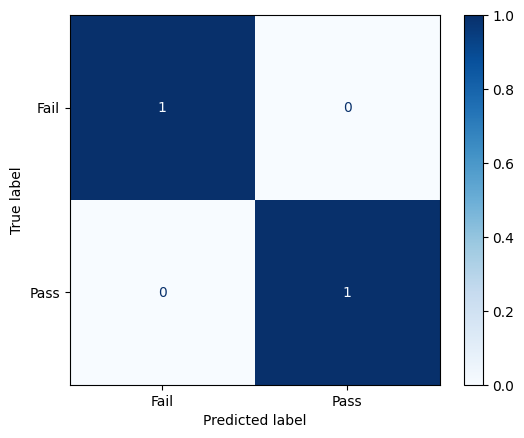

In [ ]:
#visualize the confusion matrix
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()